# InterScale Pipeline: Combined model

1. Local Model = GCN
2. Global Model = Self-attention transformer

Data: Legnini et. al. 

In [23]:
import scanpy as sc
import numpy as np

import InterScale as interscale
from InterScale.config import load_config
from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

# from graph_transformer_long_range_niches.config import load_config
# from graph_transformer_long_range_niches.pp import sliding_window

In [24]:
CFG_PATH_REG = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/Legnini_23/legnini23_genes_sample_GlobalModel.yaml"

## 0. Load and prepare data

We load a subset of the CosmX pancreas data containing T1D (type 1 diabetes) and ND (no diabetes) samples and the config file with the model specifications. 

In [25]:
cfg = load_config(CFG_PATH_REG)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 32, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 64, 'num_layers': 2, 'dropout_local': 0.0})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 128, 'dropout_global': 0.0, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 2000, 'long_range_attention': True})}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'lr': 0.001, 'use_lr_scheduler': True, 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'MSELoss', 'seed': 44, 'cross_corr': 'gene', 'n_epochs': 4000}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad', 'name': 'legnini23', 'description': '', 'predicti

In [26]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

Remove cells with zero expression across all genes. Gives error for pearson correlation.

In [27]:
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [28]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4299
       slide1_D2-3  SHH          3516
       slide1_C2-2  SHH          3350
val    slide1_B2-1  SHH          3284
train  slide4_B2-1  SHH          3175
       slide1_A2-1  SHH          3023
       slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2626
       slide4_A2-2  SHH          2505
val    slide1_B2-3  SHH          2134
test   slide4_A2-3  Ctrl         1983
train  slide1_C2-5  Ctrl         1938
test   slide4_B2-2  SHH          1772
train  slide1_B2-2  Ctrl         1699
val    slide1_A2-2  SHH          1691
       slide1_C2-3  Ctrl         1627
       slide4_B2-3  Ctrl         1622
Name: count, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [29]:
PREDICTION_TASK = 'regression'
PREDICTION_LEVEL = 'node'

prediction_obs = 'condition'
layer_key = 'log1p_norm'
sample_key = ['sample']
group_label = 'condition'

In [30]:
cfg = check_and_update_cfg(cfg, prediction_task = PREDICTION_TASK, prediction_level = PREDICTION_LEVEL, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs)

Update prediction obs (from '' to 'condition')
Update sample key (from '['sample']' to '['sample']')
Update group label (from 'condition' to 'None')


In [31]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = PREDICTION_TASK, layer_key = layer_key, sample_key_list = sample_key, prediction_obs = prediction_obs, group_key = group_label)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.0.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  group_key   │  adata.obs['_scvi_group_key']   │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

## 2. Model setup

In [32]:
model = interscale.model.CombinedModel(
    adata,
    cfg = cfg
)


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [33]:
model._model_summary_string

'regression model for node prediction. \nCombined Module: \nLocal Module: GCN Local Component: \nn_layers: 2, \nn_hidden: 64, \nn_embed: 32, \ndropout_local: 0.0\nGlobal Module: Transformer Encoder Global Component: \nmax_seq_len: 2000, \nn_heads: 4, \nact_func: relu, \nnum_layers: 2, \n\n'

## 3. Training

In [34]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs
coord_type: generic
library_key: sample
n_neighs: 6
radius: 200
call new
call new
call new
call new
Masked dataloader


In [35]:
# for now training only works with datamodule. TODO: Add DataSplitter for datamodule independent training.
model.train(max_epochs = 10, 
           datamodule = dm,
           early_stopping = True)

cross-gene per cell correlation metrics


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ictstr01/groups/ml01/workspace/francesca.drummer/ma ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.


regression
MSELoss
Regression
Steps per epoch 4


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/lightning_logs/version_36478936/checkpoints exists and is not empty.

  | Name    | Type                | Params | Mode 
--------------------------------------------------------
0 | module  | CombinedModuleClass | 36.2 K | train
1 | metrics | MetricCollection    | 0      | train
2 | loss    | MSELoss             | 0      | train
--------------------------------------------------------
36.2 K    Trainable params
0         Non-trainable params
36.2 K    Total params
0.145     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode
/ictstr01/groups/ml01/workspace/francesca.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    1.1340762376785278     │
│          val_mse          │    1.1340761184692383     │
│     val_pearson_corr      │    0.3388368785381317     │
│          val_r2           │    -0.1017744168639183    │
└───────────────────────────┴───────────────────────────┘

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:476: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    1.1859334707260132     │
│         test_mse          │    1.1859334707260132     │
│     test_pearson_corr     │    0.31709110736846924    │
│          test_r2          │    -0.1523851603269577    │
└───────────────────────────┴───────────────────────────┘

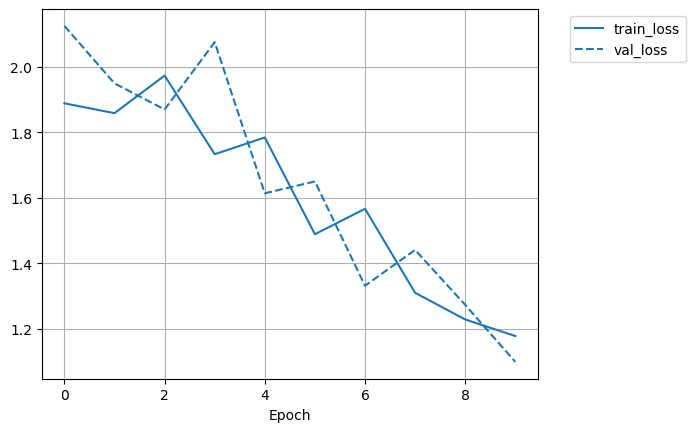

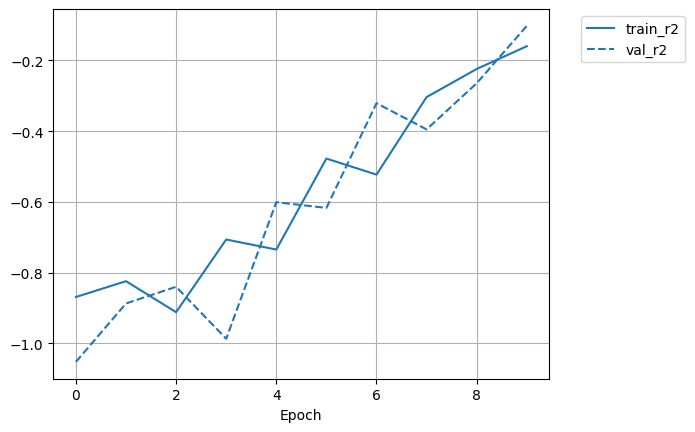

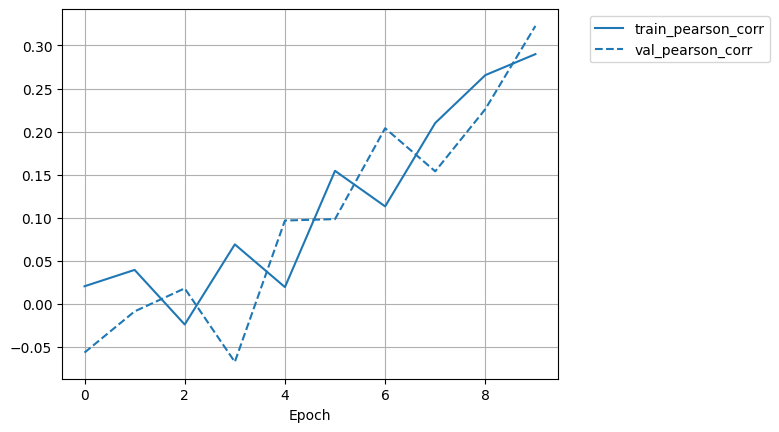

In [36]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'r2')
model.history_.plot_history(subset_term = 'pearson')

## 4. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [37]:
sub_adata = adata[adata.obs['condition'] == 'SHH']

In [47]:
result = model.get_model_output()

call new
2001
1692
2001
1700
2001
2001
2001
1628
1939
2001
2001
2001
2001
1984
2001
1773
1623


In [48]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', 'cls'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'local_emb', 'global_emb', 'attn_matrix', 'decoder_weight'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [49]:
result.obsm['decoder_weight']

array([[0.14083662629127502, 0.4465678632259369, -0.2192985862493515,
        ..., 0.693878710269928, -0.2577177882194519, 0.39101484417915344],
       [0.3478788435459137, 0.39893436431884766, -0.2005525380373001,
        ..., 0.968450129032135, -0.5400908589363098, 0.34216785430908203],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [-0.08765343576669693, 0.16783836483955383, -0.01920042373239994,
        ..., 0.1354368031024933, -0.7866548895835876, 0.6278671026229858],
       [-0.1356140375137329, 0.2004353106021881, 0.0014790474670007825,
        ..., 0.11399497836828232, -0.8545960783958435,
        0.5975806713104248],
       [-0.43122512102127075, -0.014309706166386604,
        -0.19050583243370056, ..., 0.12689073383808136,
        -0.6664366126060486, 0.7645260095596313]], dtype=object)

In [50]:
# select single slide for evaluation

In [51]:
ctrl_test = result[result.obs['sample'] == 'slide4_B2-2']
ctrl_test.obsm['attn_matrix']

ArrayView([[1.000000238418579, 1.3368642157729482e-06,
            2.2554688428044756e-07, ..., nan, nan, nan],
           [6.21485014562495e-07, 1.0000008344650269,
            5.020290814172768e-07, ..., nan, nan, nan],
           [6.370265737132286e-07, 9.999140502259252e-07,
            1.0000004768371582, ..., nan, nan, nan],
           ...,
           [2.017196862880155e-07, 1.254891117241641e-06,
            8.925354677558062e-08, ..., nan, nan, nan],
           [1.3941125587280112e-07, 1.334496118943207e-06,
            3.067793485911352e-08, ..., nan, nan, nan],
           [3.33269042585016e-07, 4.755621375807095e-06,
            6.548348778778745e-07, ..., nan, nan, nan]], dtype=object)

### Tissue level analysis

Can we detect a pattern across cells in which are more and less relevant to predict the condition? 

No cell types so need to categorize them differently. 

1. SHH expressed or not (Distance to SHH source)
2. What analysis could we perform without knowing that the SHH is the source for variation? Can we somehow trace the changes back to genes? 

### CLS token to predict the conditions

In [89]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Step 1: Prepare data
X_all = np.vstack(adata.obs['cls'].values)
y_all = adata.obs['condition'].values
samples_all = adata.obs['sample'].values

# Drop samples with NaNs
mask = ~np.isnan(X_all).any(axis=1)
X = X_all[mask]
y = y_all[mask]
samples = samples_all[mask]

# Standardize features
X = StandardScaler().fit_transform(X)

# Step 2: Fit classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Step 3: Predict and evaluate
y_pred = clf.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Step 4: Save predictions and correctness into adata.obs
adata.obs.loc[mask, 'predicted_condition'] = y_pred
adata.obs.loc[mask, 'correct_prediction'] = (y_pred == y).astype(str)  # "True"/"False" for plotting


Accuracy: 0.664


ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

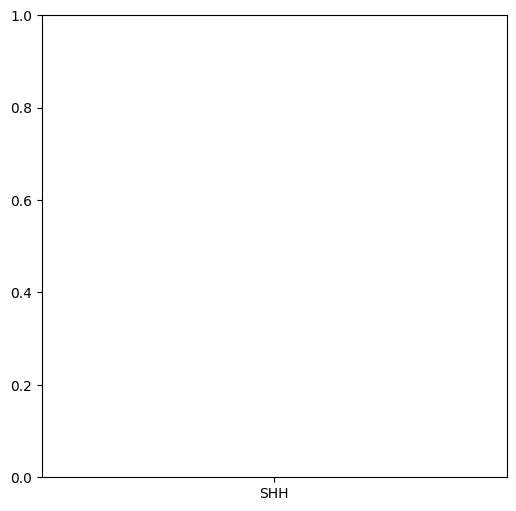

In [91]:
import matplotlib.pyplot as plt

# Suppose you have:
# coords: an (N, 2) array or DataFrame with columns ['x', 'y']
# values: a 1D array or Series with length N (values to color by)

plt.figure(figsize=(6,6))
sc = plt.scatter(y, X, color = samples, s=40)
plt.colorbar(sc, label='Value')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Spatial plot colored by 1D values')
plt.gca().invert_yaxis()  # if you want y-axis inverted (depends on data)
plt.show()


In [43]:
# plot celltype x condition 
import pandas as pd

def summarise_decoder_weight_by_group_and_condition(
    adata, 
    group_obs: str,
    condition_obs: str = '_scvi_prediction_obs', 
    decoder_weight_key: str = 'decoder_weight', 
):
    """
    Summarizes average attention weights for each (group_obs x condition_obs) combination.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention weights in adata.obsm[decoder_weight_key].
    decoder_weight_key : str
        Key for the attention weight matrix in adata.obsm.
    condition_obs : str
        Column name in adata.obs for condition (e.g., 'disease_status').
    group_obs : str
        Column name in adata.obs for group (e.g., 'cell_type').
        
    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with average attention weights for each group x condition.
        Rows: (group_obs, condition_obs)
        Columns: attention per target cell type (from decoder_weight_key).
    """
    # Extract relevant data
    weight = adata.obsm[decoder_weight_key]
    group = adata.obs[group_obs]
    condition = adata.obs[condition_obs]
    
    # Create DataFrame for easy grouping
    df = pd.DataFrame(
        weight, 
        columns=[f"{decoder_weight_key}_{i}" for i in range(weight.shape[1])]
    )
    df[group_obs] = group.values
    df[condition_obs] = condition.values
    
    # Group by group_obs and condition_obs, then average
    grouped = df.groupby([group_obs, condition_obs]).mean()
    
    return grouped

In [44]:
summarise_decoder_weight_by_group_and_condition(
    result, 
    condition_obs = 'shh_cluster', 
    group_obs = 'condition'
)

KeyError: 'shh_cluster'

In [ ]:
from scipy.stats import pearsonr
import torch
import numpy as np

y_pred_np = torch.tensor([[0.1, 0.2, 0.3],
                         [0.15, 0.25, 0.35]])
y_true_np = torch.tensor([[0.0, 0.4, 0.6],
                        [0.0, 0.34, 0.43]])

pearson_corr_raw = pearsonr(y_pred_np, y_true_np)
pearson_corr = torch.tensor(np.nanmean(pearson_corr_raw[0]), 
                                      dtype=torch.float32, 
                                      device=y_pred_np.device)

In [ ]:
pearson_corr

In [ ]:
pearson_corr_raw